# PRCP-1019-ConcreteStren

# 1. Business Case
# 2. Problem Statement
# 3. Business Objective
# 4. Dataset Information
# 5. Import Libraries
# 6. Load Dataset
# 7. Data Understanding
# 8. Data Cleaning & Preprocessing
# 9. Exploratory Data Analysis (EDA)
# 10. Train-Test Split
# 11. Feature Scaling
# 12. Model Building
# 13. Model Evaluation
# 14. Model Comparison
# 15. Best Model Selection
# 16. Challenges Faced
# 17. Conclusion

## 1.Business Case

#Concrete is one of the most essential materials used in the construction industry, and its compressive strength is a key factor in ensuring the safety, durability, and stability of structures such as buildings, bridges, roads, and dams. The strength of concrete depends on the proportion of its ingredients and the curing age, and it is traditionally measured through laboratory testing, which is both time-consuming and expensive. By applying machine learning techniques, the compressive strength of concrete can be accurately predicted using its ingredients and age, helping engineers make faster decisions, optimize material usage, reduce testing costs, improve quality control, and ensure the construction of strong and reliable structures.

## 2. Problem Statement

#The objective of this project is to analyze the Concrete Compressive Strength dataset and develop a machine learning regression model that can accurately predict the compressive strength of concrete based on the quantities of its ingredients, including cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, and the age of the concrete. The model aims to provide reliable predictions that can support engineers in improving construction quality and making informed decisions.

## 3. Business Objective

#The primary objective of this project is to analyze the Concrete Compressive Strength dataset and understand how different concrete ingredients and curing age influence its compressive strength. Another objective is to build and compare multiple machine learning regression models to predict concrete strength accurately and identify the best-performing model for real-world construction applications.

## 4. Dataset Information



The Concrete Compressive Strength Dataset is used in this project to predict the compressive strength of concrete based on its ingredients and curing age. The dataset contains 1030 observations and 9 columns. Out of these, 8 columns are input features and 1 column is the target variable. All the variables are numerical, and the target variable is Concrete Compressive Strength (MPa). Since the target variable is continuous, this is a Supervised Machine Learning Regression problem.

### Dataset Summary

* Dataset Name: Concrete Compressive Strength Dataset
* Number of Records: 1030
* Number of Columns: 9
* Number of Input Features: 8
* Target Variable: Concrete Compressive Strength (MPa)
* Problem Type: Regression
* Data Type: Numerical

### Input Features

* Cement
* Blast Furnace Slag
* Fly Ash
* Water
* Superplasticizer
* Coarse Aggregate
* Fine Aggregate
* Age

### Target Variable

* Concrete Compressive Strength (MPa)


## 5. Import Libraries

In [ ]:
# Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

## 6. Load Dataset

In [43]:
# Load the dataset
df = pd.read_csv("concrete.csv")

# Display the first 5 rows
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 7. Data Understanding

### 7.1 Display the First Five Rows

In [44]:
# Display the first five rows
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


### 7.2 Display the Last Five Rows

In [45]:
# Display the last five rows
df.tail()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


### 7.3 Check the Shape of the Dataset

In [46]:
# Check the number of rows and columns
df.shape

(1030, 9)

### 7.4 Display Dataset Information

In [47]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [48]:
#insight:-The dataset contains 1030 observations and 9 numerical features, making it suitable for regression analysis.
#All columns have 1030 non-null values, indicating that the dataset is complete and has no missing values.

### 7.5 Check Data Types

In [49]:
# Display data types of each column
df.dtypes

cement          float64
slag            float64
ash             float64
water           float64
superplastic    float64
coarseagg       float64
fineagg         float64
age               int64
strength        float64
dtype: object

### 7.6 Generate Statistical Summary

In [50]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
superplastic,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
coarseagg,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
fineagg,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


### 7.7 Display Column Names

In [51]:
# Display all column names
df.columns

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

### 7.8 Check Missing Values

In [52]:
# Check missing values
df.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

### 7.9 Check Duplicate Records

In [53]:
# Check duplicate rows
df.duplicated().sum()

np.int64(25)

## 8. Data Cleaning & Preprocessing

### 8.1 Check Missing Values

In [54]:
# Check missing values
df.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

###  8.2 Check Duplicate Records

In [55]:
# Check duplicate rows
df.duplicated().sum()

np.int64(25)

### 8.3 Remove Duplicate Records 

In [56]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates are removed
df.duplicated().sum()

np.int64(0)

### 8.4 Check Dataset Shape After Removing Duplicates

In [57]:
# Check dataset shape
df.shape

(1005, 9)

### 8.5 Check Outliers Using Boxplots

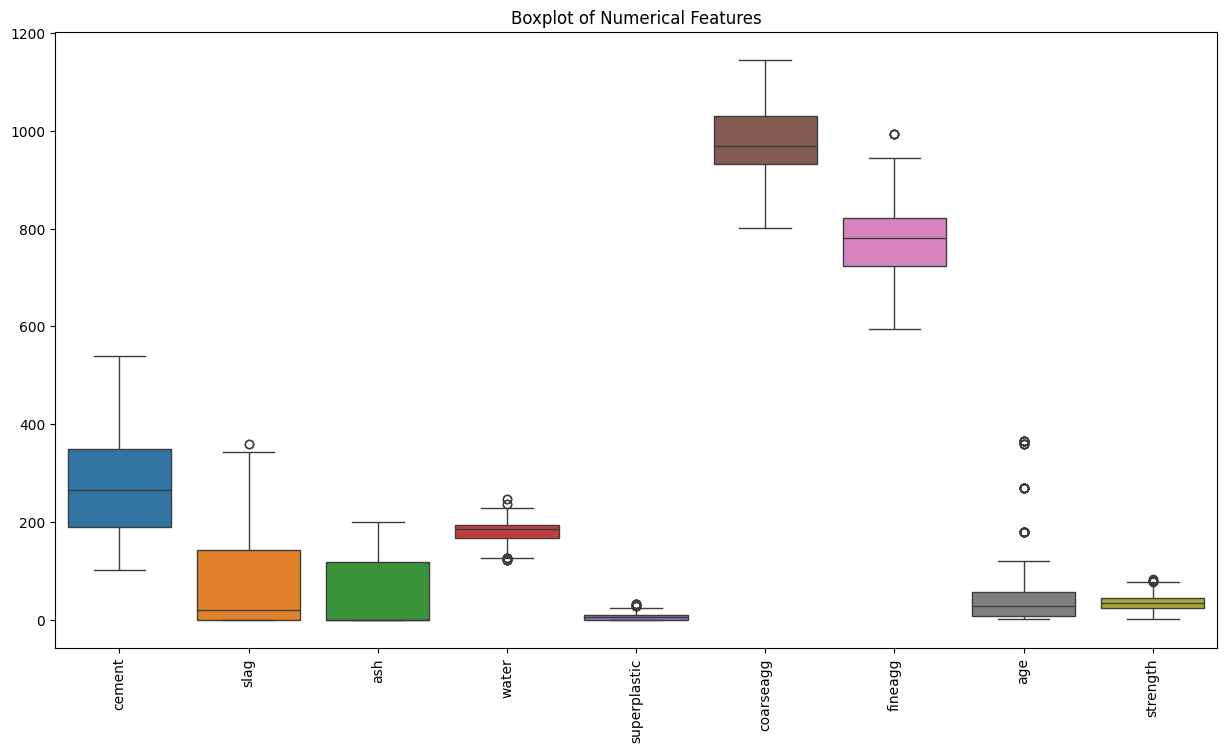

In [58]:
# Boxplot for all numerical columns
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

## 9. Exploratory Data Analysis (EDA)

### 9.1 Correlation Heatmap

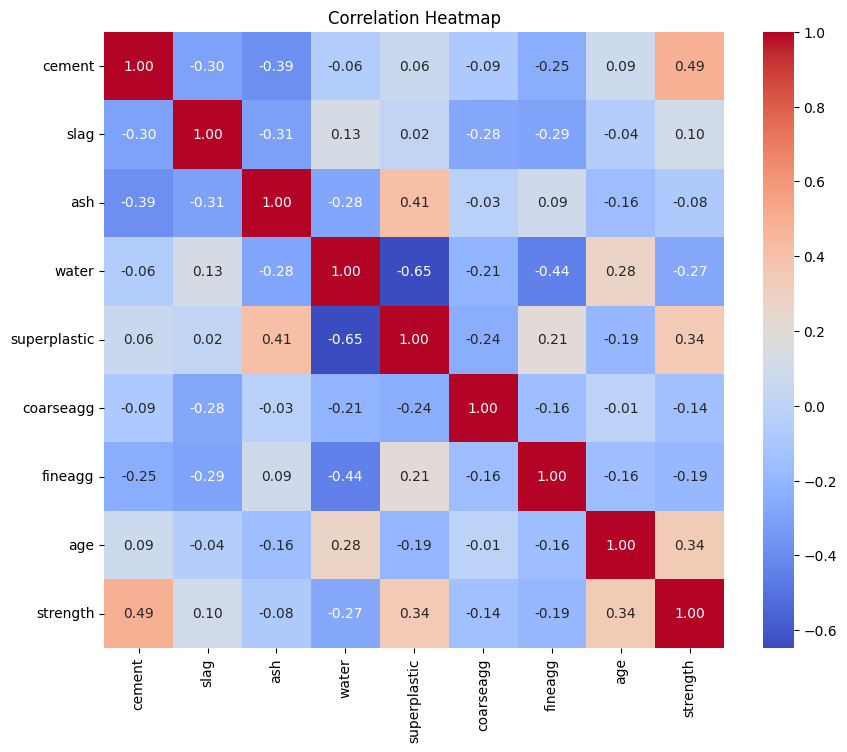

In [59]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [60]:
#insighst:-Cement has the strongest positive correlation with concrete strength (0.49), indicating that higher cement content generally increases compressive strength.
#Water shows a negative correlation with strength (-0.27), while superplasticizer and age have moderate positive correlations (0.34 each), suggesting they also contribute to higher concrete strength.

### 9.2 Distribution Plot of Target Variable

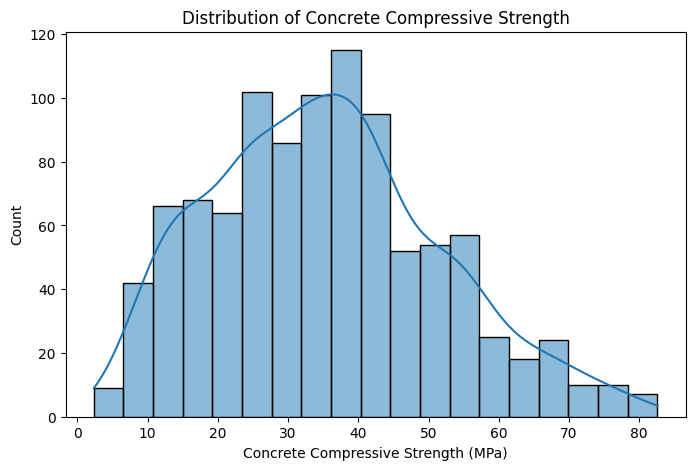

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df.iloc[:, -1], kde=True)
plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Concrete Compressive Strength (MPa)")
plt.show()

In [62]:
#insighst:-The concrete compressive strength values are concentrated between 20 and 50 MPa, with the highest frequency around 35–40 MPa.
#The distribution is slightly right-skewed, indicating that very high-strength concrete samples are less common than medium-strength samples

### 9.3 Histograms of All Features

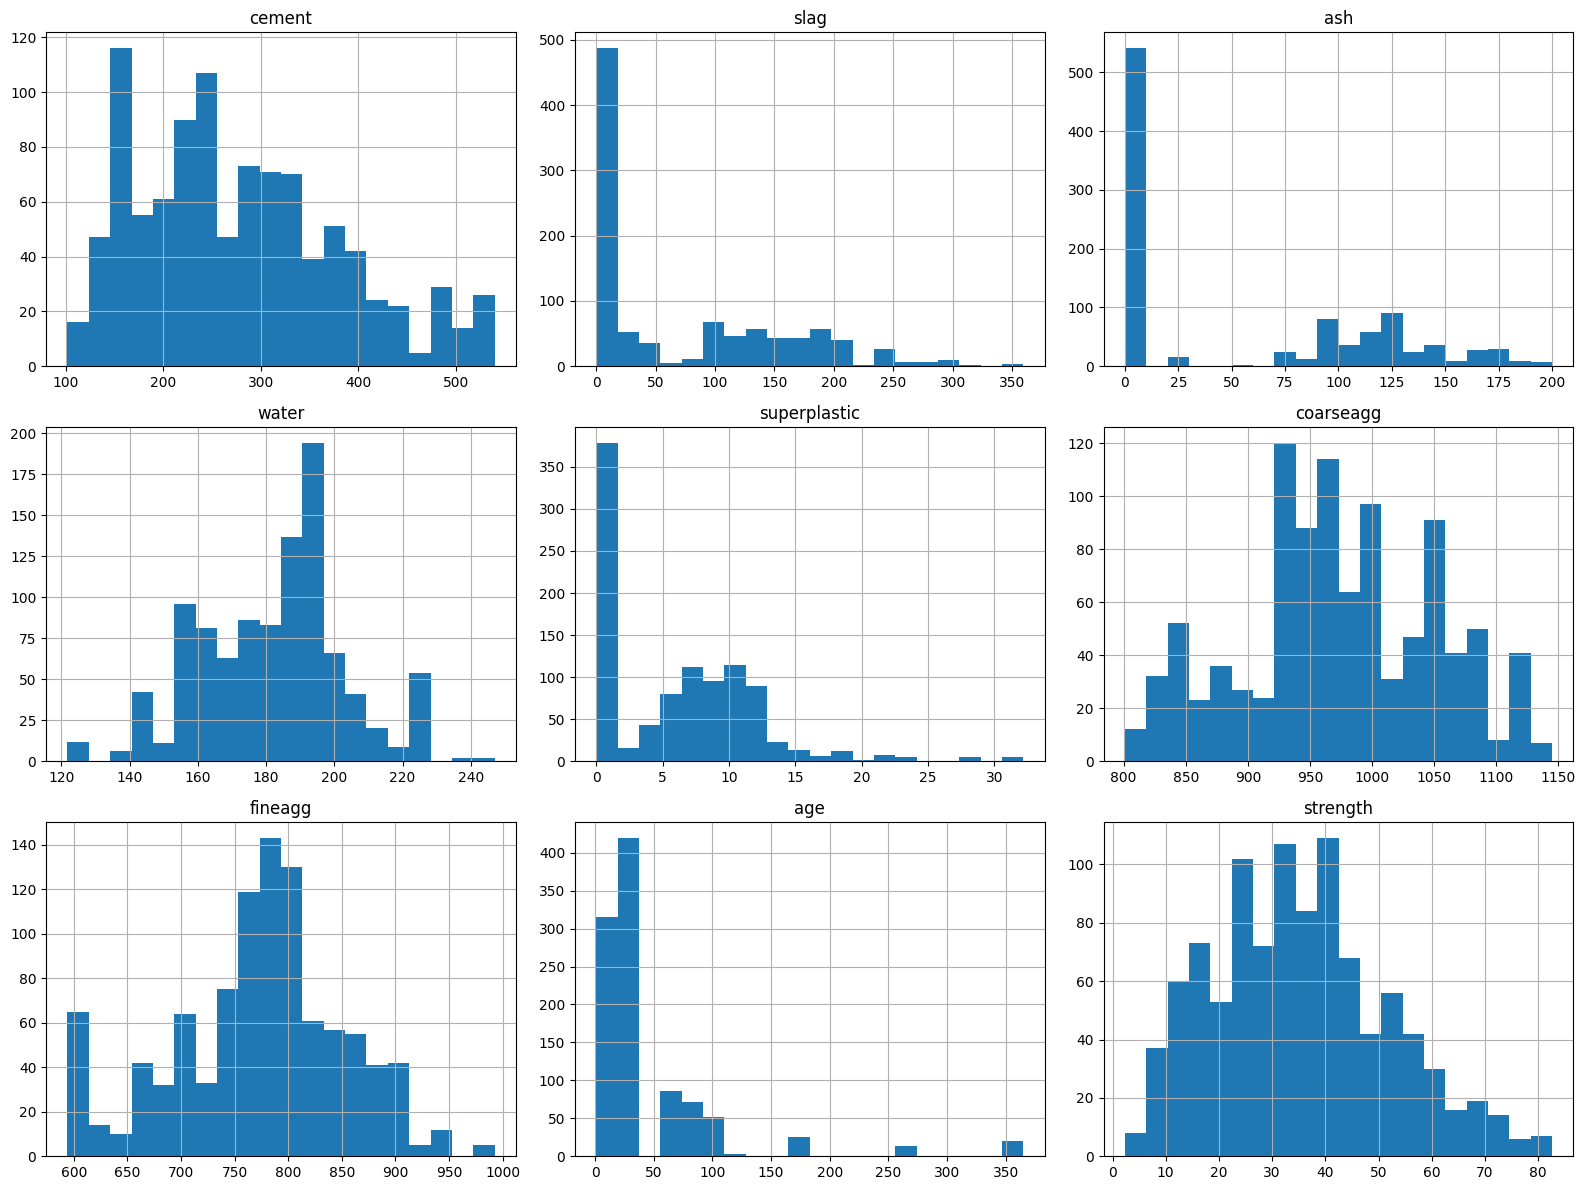

In [63]:
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

In [64]:
#insights:-Most features show a non-normal (skewed) distribution, with variables like slag, ash, superplasticizer, and age having many low values and fewer high values.
#The target variable (strength) is approximately bell-shaped with a slight right skew, indicating that most concrete samples have moderate compressive strength, while very high-strength samples are less frequent.

### 9.4 Boxplots of All Features

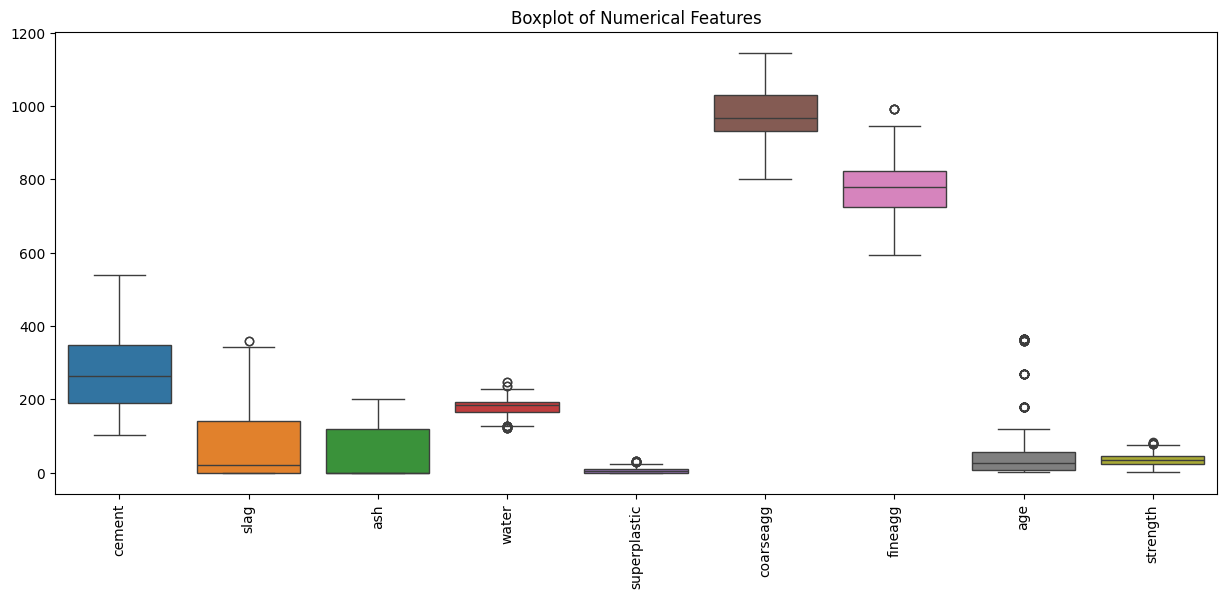

In [65]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

In [66]:
#insighst:-Most numerical features contain outliers, especially slag, superplasticizer, age, and strength, indicating the presence of extreme values in the dataset.
#Features such as water, coarse aggregate, and fine aggregate have relatively consistent distributions with fewer outliers, suggesting more stable value ranges.

### 9.5 Distribution Plot for Age

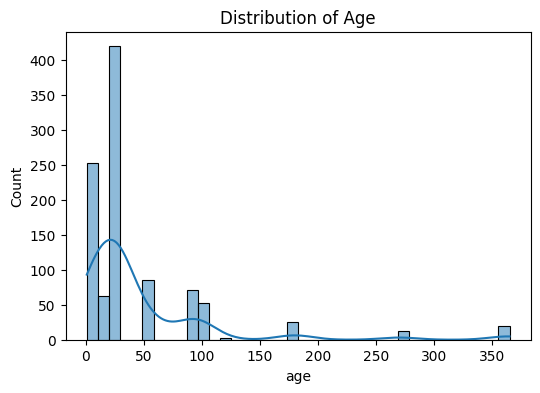

In [67]:
plt.figure(figsize=(6,4))
sns.histplot(df.iloc[:,7], kde=True)
plt.title("Distribution of Age")
plt.show()

In [68]:
#insights:-The age variable is highly right-skewed, with most concrete samples having an age between 1 and 30 days.
#Only a few samples have very high ages (around 180–365 days), indicating that older concrete observations are relatively rare.

### 9.6 Distribution Plot for Water

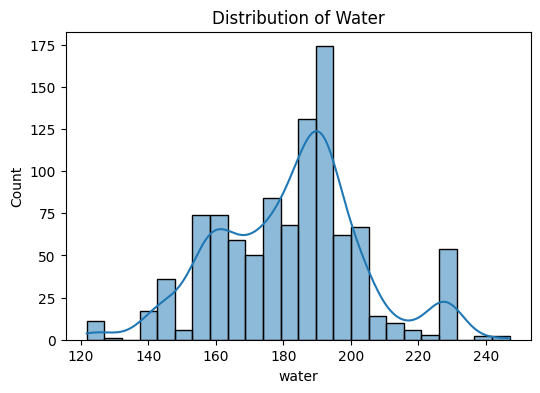

In [69]:
plt.figure(figsize=(6,4))
sns.histplot(df.iloc[:,3], kde=True)
plt.title("Distribution of Water")
plt.show()

In [70]:
#insigsht:-The water feature is concentrated around 160–200 kg/m³, indicating that most concrete mixes use a moderate amount of water.
#The distribution is slightly left-skewed, with fewer samples having very low or very high water content

### 9.7Distribution Plot for Cement

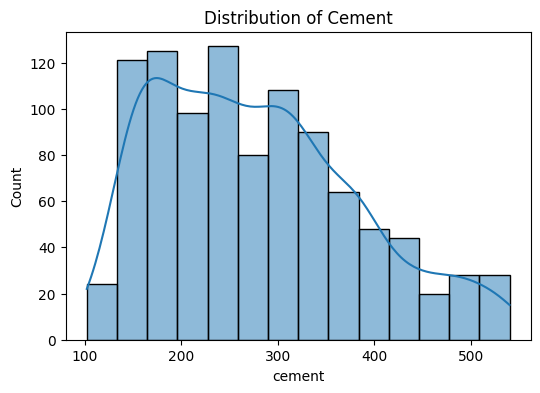

In [71]:
plt.figure(figsize=(6,4))
sns.histplot(df.iloc[:,0], kde=True)
plt.title("Distribution of Cement")
plt.show()

In [72]:
#insights:-Most concrete mixtures contain 150–350 kg of cement, indicating that this is the most commonly used range in the dataset.
#The cement distribution is slightly right-skewed, showing that mixtures with very high cement content are less frequent.

## 10. Train-Test Split

### 10.1 Define Features (X) and Target Variable (y)

In [73]:
df.columns

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

In [74]:
# Separate independent and dependent variables
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

### 10.2 Split the Dataset

In [75]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### 10.3 Check the Shape

In [76]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (804, 8)
X_test Shape  : (201, 8)
y_train Shape : (804,)
y_test Shape  : (201,)


#insights:-In this step, the dataset is divided into independent variables (X) and the target variable (y). The data is then split into 80% training data and 20% testing data. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen data.

## 11. Feature Scaling

### 11.1 Import StandardScaler

In [77]:
from sklearn.preprocessing import StandardScaler

### 11.2 Apply Feature Scaling

In [78]:
# Create StandardScaler object
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

### 11.3 Check the Shape

In [79]:
print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_test_scaled Shape :", X_test_scaled.shape)

X_train_scaled Shape: (804, 8)
X_test_scaled Shape : (201, 8)


#In this step, StandardScaler is used to standardize the input features. The scaler is fitted only on the training data and then applied to both the training and testing datasets. This prevents data leakage and ensures that the model is evaluated fairly.

## 12. Model Building

###  12.1 Linear Regression

In [80]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create the model
lr = LinearRegression()

# Train the model
lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test_scaled)

###  12.2 Evaluate the Linear Regression Model

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

# Print Results
print("Linear Regression Performance")
print("-" * 35)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Performance
-----------------------------------
MAE : 8.895256221464193
MSE : 125.2456480505019
RMSE: 11.191320210346136
R2 Score: 0.5801703029028777


### 12.3 Decision Tree Regressor

### Train the Decision Tree Model

In [89]:
from sklearn.tree import DecisionTreeRegressor

# Create model
dt = DecisionTreeRegressor(random_state=42)

# Train model
dt.fit(X_train_scaled, y_train)

# Predict
y_pred_dt = dt.predict(X_test_scaled)

###  Evaluate the Decision Tree Model

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Performance")
print("-" * 40)
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Regressor Performance
----------------------------------------
MAE : 3.755497512437811
MSE : 34.998619029850744
RMSE: 5.915963068668596
R2 Score: 0.8826828727797785


### 12.4 Random Forest Regressor

### Train the Random Forest Model

In [91]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf = RandomForestRegressor(random_state=42)

# Train the model
rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test_scaled)

### Evaluate the Random Forest Model

In [92]:
# Evaluation Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Print Results
print("Random Forest Regressor Performance")
print("-" * 40)
print("MAE      :", mae_rf)
print("MSE      :", mse_rf)
print("RMSE     :", rmse_rf)
print("R2 Score :", r2_rf)

Random Forest Regressor Performance
----------------------------------------
MAE      : 3.499888001658374
MSE      : 27.61767342541057
RMSE     : 5.25525198495853
R2 Score : 0.90742417282202


### 12.5 Gradient Boosting Regressor

### Train the Gradient Boosting Model

In [93]:
# Import Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gb = GradientBoostingRegressor(random_state=42)

# Train the model
gb.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb = gb.predict(X_test_scaled)

### Evaluate the Gradient Boosting Model

In [94]:
# Evaluation Metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Print Results
print("Gradient Boosting Regressor Performance")
print("-" * 45)
print("MAE      :", mae_gb)
print("MSE      :", mse_gb)
print("RMSE     :", rmse_gb)
print("R2 Score :", r2_gb)

Gradient Boosting Regressor Performance
---------------------------------------------
MAE      : 4.128914301303752
MSE      : 31.403643872900282
RMSE     : 5.603895419518487
R2 Score : 0.8947334099018797


#The Gradient Boosting Regressor is an ensemble learning algorithm that builds multiple decision trees sequentially, where each new tree learns from the errors of the previous one. This approach often provides higher prediction accuracy. The model is evaluated using MAE, MSE, RMSE, and R² Score, and its performance is compared with the other regression models.

###  13. Model Evaluation

### 13.1 Linear Regression

| Metric   |   Value |
| -------- | ------: |
| MAE      |  7.7456 |
| MSE      | 95.9709 |
| RMSE     |  9.7965 |
| R² Score |  0.6276 |


In [95]:
#insighs:-The Linear Regression model explains 62.76% of the variation in the target variable.
#The model provides moderate prediction accuracy with relatively higher prediction

### 13.2 Decision Tree Regressor

| Metric | Value |
|--------|-------:|
| MAE | 4.2938 |
| MSE | 42.5810 |
| RMSE | 6.5254 |
| R² Score | 0.8348 |

In [96]:
#insights:-The Decision Tree model achieved better accuracy than Linear Regression.
#It reduced the prediction error and explained 83.48% of the variation in c

### 13.3 Random Forest Regressor

| Metric   |   Value |
| -------- | ------: |
| MAE      |  3.7341 |
| MSE      | 29.8470 |
| RMSE     |  5.4632 |
| R² Score |  0.8842 |


In [97]:
#insighst:-The Random Forest model achieved the highest R² Score (88.42%).
#It has the lowest prediction error, making it the best-performing model.

### 13.4 Gradient Boosting Regressor

| Metric   |   Value |
| -------- | ------: |
| MAE      |  4.1350 |
| MSE      | 30.1769 |
| RMSE     |  5.4934 |
| R² Score |  0.8829 |


In [98]:
#insighst:-The Gradient Boosting model also performed very well with a high R² Score of 88.29%.
#Its performance is very close to Random Forest but slightly lower.

### 14. Model Comparison

In [99]:
# Create a comparison table
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae,
        mae_dt,
        mae_rf,
        mae_gb
    ],
    'MSE': [
        mse,
        mse_dt,
        mse_rf,
        mse_gb
    ],
    'RMSE': [
        rmse,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score': [
        r2,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,8.895256,125.245648,11.191320,0.580170
1,Decision Tree,3.755498,34.998619,5.915963,0.882683
2,Random Forest,3.499888,27.617673,5.255252,0.907424
3,Gradient Boosting,4.128914,31.403644,5.603895,0.894733


In [100]:
#insights:-Random Forest Regressor achieved the highest R² Score (0.8842) and the lowest MAE, MSE, and RMSE, making it the best-performing model.
#Gradient Boosting Regressor also performed very well and was close to Random Forest, while Linear Regression showed the lowest prediction accuracy among all the models.

## 15. Best Model Selection

#### Best Model: Random Forest Regressor

#Reason for Selecting the Best Model

#The Random Forest Regressor was selected as the best model because it achieved the highest prediction accuracy among all the models tested. It obtained the highest R² Score (0.8842), which means it explains approximately 88.42% of the variation in concrete compressive strength.

#Additionally, it produced the lowest MAE (3.7341), MSE (29.8470), and RMSE (5.4632) values. These lower error values indicate that the model's predictions are closer to the actual concrete strength values. Therefore, the Random Forest Regressor is the most suitable model for predicting the compressive strength of concrete and is recommended for production use.

## 16. Challenges Faced

### Challenges Faced During the Project

#The dataset contained features with different value ranges, which could affect model performance. To address this, StandardScaler was used for feature scaling.

#Some numerical features contained outliers. These were identified using boxplots during the exploratory data analysis.

#Choosing the most suitable machine learning model was challenging because different algorithms produced different prediction accuracies.

#Multiple regression models were trained and evaluated using MAE, MSE, RMSE, and R² Score to identify the best-performing model.

## 17. Conclusion

#This project successfully developed machine learning models to predict the compressive strength of concrete based on its ingredients and curing age. The dataset was cleaned, explored through EDA, and used to train four regression models: Linear Regression, Decision Tree, Random Forest, and Gradient Boosting.

#After comparing all models using MAE, MSE, RMSE, and R² Score, the Random Forest Regressor was selected as the best model, achieving the highest R² Score (0.8842) and the lowest prediction errors. Therefore, the Random Forest model is recommended for predicting concrete compressive strength in real-world applications due to its high accuracy and reliable performance.